In [1]:
import os
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"   
os.environ["CUDA_VISIBLE_DEVICES"]="2,3"

%load_ext autoreload
%autoreload 2


In [2]:
import os
import sys


PROJECT_ROOT = os.getcwd()
if os.path.basename(PROJECT_ROOT) == "notebooks_causal_cactus":
    PROJECT_ROOT = os.path.dirname(PROJECT_ROOT)
os.chdir(PROJECT_ROOT)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.DataReaders import *
from src.address import *
from src.modelGen import *
from src.utils import cf_eval, cleanup_gpu, LOF_context_score
from models import CF_CausalCondLatentCF, CF_LatentCFpp, CF_PrototypeCF, CF_CondLatentCF
import numpy as np
import random 
from tensorflow import random as tf_random
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from itertools import product
import argparse
import pandas as pd
import tensorflow as tf



2026-06-23 00:09:16.325497: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
SEED = 23

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf_random.set_seed(SEED)


CF_METHODS = {  
    "LatentCFpp": CF_LatentCFpp,
    "Prototype": CF_PrototypeCF,
    "CausalCACTUS": CF_CausalCondLatentCF,
    "CACTUS": CF_CondLatentCF
}


In [4]:
# Experimentos a realizar
EXP_CONFIG_PATH = os.path.join(PROJECT_ROOT, "configs", "experiments", "GERMANCREDIT_EXP.json")
with open(EXP_CONFIG_PATH, encoding="utf-8") as f:
    EXP = json.load(f)


In [ ]:
# Loading data
CLASS_CONFIG_PATH = EXP[0]["classifier"]
class_config = get_exp_config(CLASS_CONFIG_PATH)
data   = getData(class_config)

# Getting the classifier
classifier = modelGen(class_config["type"], data,params=class_config, debug=True)
classifier.load()

In [6]:
# Select test data
X_test = data.X_test
y_test_onehot = data.y_test
context_test = data.context_test

X_original = []
y_original_onehot = []
context_original = []

N = min(50,len(X_test))
SELECTED_IDX = []


idx = np.random.choice(len(X_test), N, replace=False)


X_original = X_test[idx]
y_original_onehot = y_test_onehot[idx]
context_original = context_test.values[idx]

lof_original = LOF_context_score(
    data.X_train,
    data.context_train.values,
    X_original,
    context_original,
    agg=False
)

In [7]:
import re
from collections import defaultdict
# TODO: make a function to convert the causal paths for all the test samples
def build_causal_index_map(input_features, graph_str):
    """
    Returns:
        child_to_parents: dict {child_idx: [parent_idx, ...]}
        parent_to_children: dict {parent_idx: [child_idx, ...]}
        feat2idx: dict {feature_name: index}
    """

    # Feature name to index
    feat2idx = {f: i for i, f in enumerate(input_features)}

    # Extract edges using regex
    edges = re.findall(r'(\w+)\s*->\s*(\w+)', graph_str)

    child_to_parents = defaultdict(list)
    parent_to_children = defaultdict(list)

    for parent, child in edges:

        if parent not in feat2idx or child not in feat2idx:
            raise ValueError(f"Feature in graph not found in dataset: {parent} or {child}")

        p_idx = feat2idx[parent]
        c_idx = feat2idx[child]

        child_to_parents[c_idx].append(p_idx)
        parent_to_children[p_idx].append(c_idx)

    return dict(child_to_parents), dict(parent_to_children), feat2idx




# 
graph_str2 = """ 
strict digraph {
CreditAmount;
Duration;
Age;
CheckingAccount;
Sex;
Job;
SavingAccounts;
Housing;
SavingAccounts -> Job;
SavingAccounts -> CheckingAccount;
Housing -> CheckingAccount;
Housing -> Job;
}
"""

In [ ]:


#########
# Context-preserving CF generation
#########
X_cf_list = []
y_cf_labels_list = []
X_internal_list = []
y_internal_list = []
lof_cf_list = []
cf_scores_list = []
cf_scores_labels_list = []

for exp_id, exp in enumerate(EXP):

    AE_CONFIG_PATH = exp["AEmodel"]
    AE_config = get_exp_config(AE_CONFIG_PATH)

    ae_model = modelGen(
        AE_config["type"],
        data,
        params=AE_config,
        debug=True
    )
    ae_model.load()

    y_original_labels = np.argmax(y_original_onehot, axis=1)
    y_original_logits = classifier.predict(X_original)

    # NOTE: updated
    child_to_parents_dict, parent_to_children_dict, feat2idx = build_causal_index_map(
        data.features_lbls,
        graph_str2
    )
    print("Feature → index:")
    print(feat2idx)
    print("\nChild → Parents (index form):")
    print(child_to_parents_dict)

    if exp["name"] == "CausalCACTUS":
        CF_method = CF_METHODS[exp["CFmethod"]](
            classifier=classifier,
            # gen=aeModel,
            gen=ae_model,
            params=exp,
            x=data.X_train,
            y=data.y_train,
            x_min=data.X_train.min(axis=0),
            x_max=data.X_train.max(axis=0),
            causal_index_map=child_to_parents_dict
        )
    else:
        CF_method = CF_METHODS[exp["CFmethod"]](
            classifier=classifier,
            # gen=aeModel,
            gen=ae_model,
            params=exp,
            x=data.X_train,
            y=data.y_train
        )

    X_cf, y_cf_labels, X_internal, y_internal = CF_method.transform(
        X_original,
        y_original_labels,
        target_context=context_original
    )

    lof_cf = LOF_context_score(
        data.X_train,
        data.context_train.values,
        X_cf,
        context_original,
        agg=False
    )
    
    # --- CF evaluation ---
    cf_scores, cf_scores_labels = cf_eval(
        X_train=data.X_train, # previous name: data.X_train
        context_train=data.context_train, # previous name: context_training,
        X=X_internal, # previous name: x,
        CF_X=X_cf, # previous name: cf_x, 
        pred_labels=y_original_labels, # previous name: y_,
        target_context=context_original, # previous name: context,
        CF_labels=y_cf_labels, # previous name: cf_y_
        X_unscaled=data.scaler_inverse_transform(X_internal),
        CF_X_unscaled=data.scaler_inverse_transform(X_cf),
        child_to_parents_dict=child_to_parents_dict,
        average=False
    )

    # X_cf = data.scaler_inverse_transform(X_cf) # TODO: non scale

    X_cf_list.append(X_cf)
    y_cf_labels_list.append(y_cf_labels)
    X_internal_list.append(X_internal)
    y_internal_list.append(y_internal)
    lof_cf_list.append(lof_cf)
    cf_scores_list.append(cf_scores)
    cf_scores_labels_list.append(cf_scores_labels)

    cleanup_gpu()


# Heat map $\Delta(x)$ (with normalized data)
Delta heatmap without dernormalizing the data

In [ ]:
## Setting up data
# Original samples "scaled"
print(X_original.shape)
# List for all CF generated in all exps
print(len(X_cf_list))
# List of exps
print([exp["name"] for exp in EXP])
# List of feats
print(data.features_lbls)
# Original samples 
X_original_unscaled = data.scaler_inverse_transform(X_original)
# Denormalized CF samples 
X_cf_unscaled_list = [data.scaler_inverse_transform(x_cf)  for x_cf in X_cf_list] 

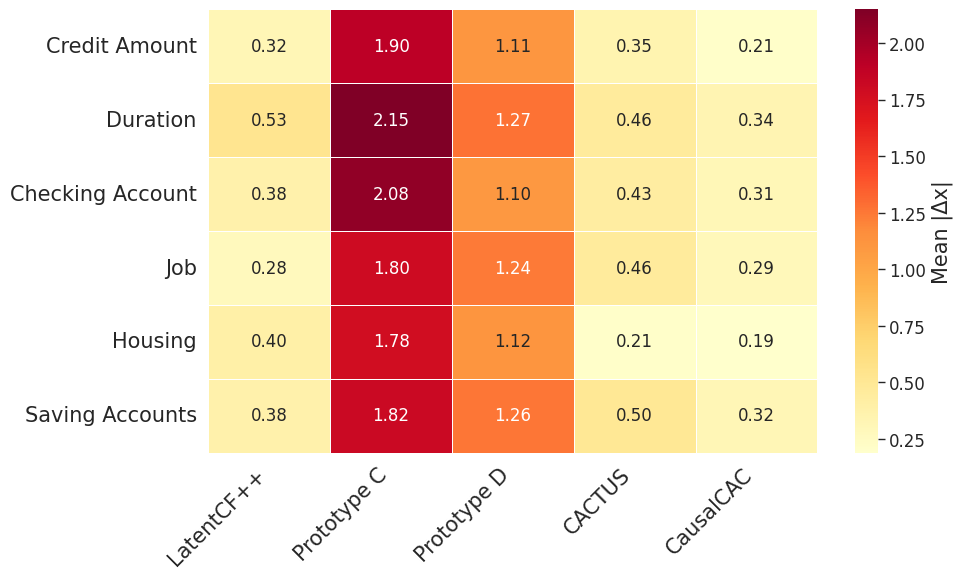

In [10]:
import seaborn as sns

# -----------------------------
# Compute aggregated |Δx|
# -----------------------------

feature_names = ['Credit Amount',
                'Duration',
                'Checking Account',
                'Job',
                'Housing',
                'Saving Accounts']


exp_names = ["LatentCF++", "Prototype C","Prototype D","CACTUS","CausalCAC"]

agg_deltas = []

for x_cf in X_cf_list:
    delta = np.abs(x_cf - X_original)   # |Δx|
    agg_deltas.append(delta.mean(axis=0))        # aggregate over samples
    

# Shape: (num_experiments, num_features)
agg_deltas = np.vstack(agg_deltas)
agg_deltas = np.round(agg_deltas,2)
# Create DataFrame (features as rows, experiments as columns)
df_heatmap = pd.DataFrame(
    agg_deltas.T,
    index=feature_names,
    columns=exp_names
)

# -----------------------------
# Seaborn / Matplotlib paper style
# -----------------------------
sns.set_theme(
    context="paper",
    style="white",
    font_scale=1.4   # global scale (adjustable)
)

# -----------------------------
# Plot heatmap
# -----------------------------
plt.figure(figsize=(10, 6))

ax = sns.heatmap(
    df_heatmap,
    cmap="YlOrRd",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Mean |Δx|"},
    annot_kws={"size": 12}   # numbers inside the heatmap
)


# Tick labels
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    ha="right",
    fontsize=15
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=15
)

# Colorbar label & ticks
cbar = ax.collections[0].colorbar
cbar.set_label("Mean |Δx|", fontsize=15)
cbar.ax.tick_params(labelsize=12)

plt.tight_layout()
plt.savefig("results/4_1_4_german_credit_mean_absolute_feature_change.pdf", format="pdf", bbox_inches="tight")
plt.show()

#TODO indicate the graph structure in the Heatmap

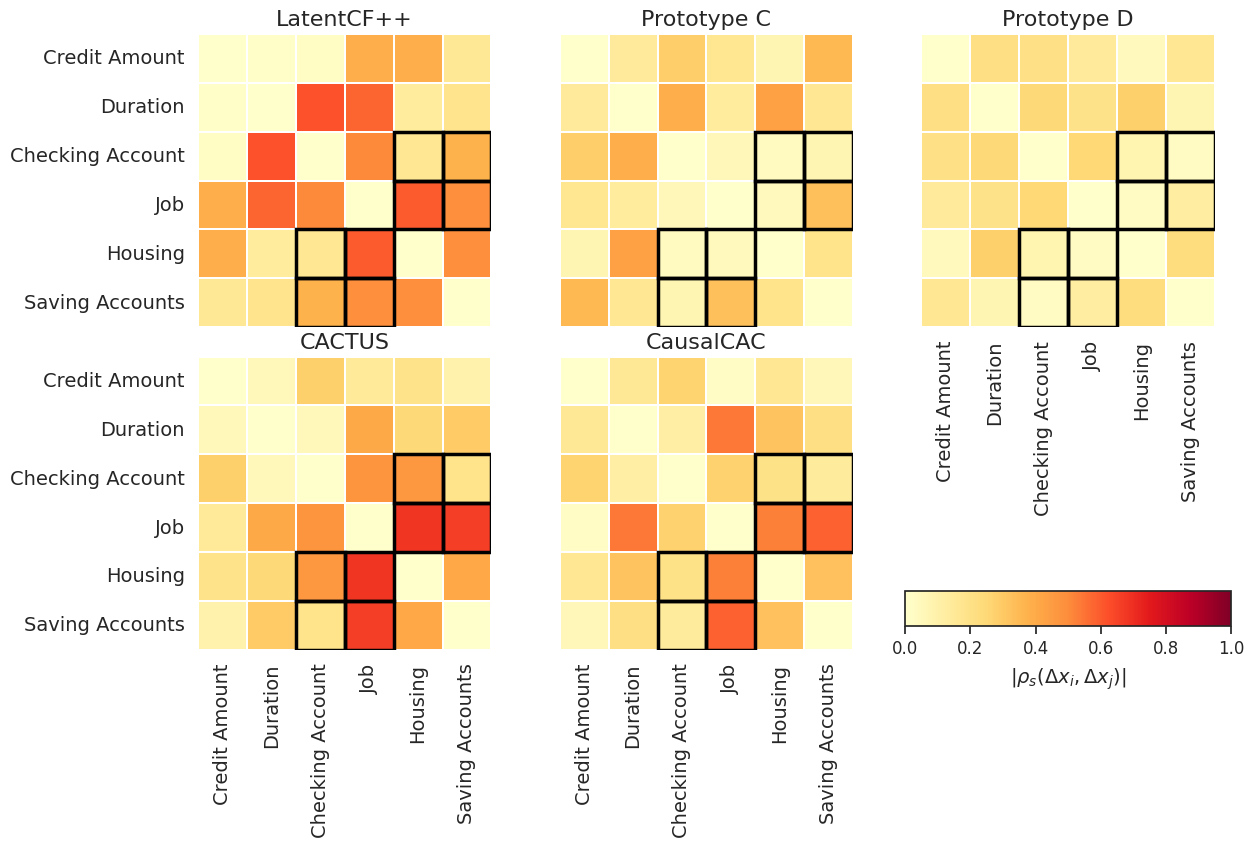

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# -----------------------------
# Setup
# -----------------------------
feature_names = ['Credit Amount',
                'Duration',
                'Checking Account',
                'Job',
                'Housing',
                'Saving Accounts']

exp_names = ["LatentCF++", "Prototype C","Prototype D","CACTUS","CausalCAC"]
d = X_original_unscaled.shape[1]

# Build list of (row, col) indices to highlight
highlight_pairs = []
for child, parents in child_to_parents_dict.items():
    for parent in parents:
        highlight_pairs.append((child, parent))   # (row=child, col=parent)
        highlight_pairs.append((parent, child))   # symmetric cell
highlight_pairs = list(set(highlight_pairs))      # remove duplicates

# -----------------------------
# Compute |Spearman| correlation matrices
# -----------------------------
corr_mats = []
for x_cf in X_cf_list:
    delta = x_cf - X_original
    corr, _ = spearmanr(delta, axis=0)
    corr = np.asarray(corr).reshape(d, d)
    C = np.abs(corr)
    np.fill_diagonal(C, 0.0)
    corr_mats.append(C)

# -----------------------------
# Plot (5 matrices) + colorbar in subplot 6
# -----------------------------
sns.set(style="white")

fig, axes = plt.subplots(
    2, 3,
    figsize=(14, 8),
    gridspec_kw={"wspace": 0.0, "hspace": 0.1}
)
axes = axes.flatten()

cmap = "YlOrRd"
vmin, vmax = 0.0, 1.0

# Plot only the first 5 heatmaps (leave axes[5] for the colorbar)
for i, (ax, name, C) in enumerate(zip(axes[:5], exp_names, corr_mats)):
    sns.heatmap(
        C,
        ax=ax,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        square=True,
        xticklabels=feature_names if i >= 2 else False,       # bottom row only
        yticklabels=feature_names if i % 3 == 0 else False,   # leftmost col only
        cbar=False,
        linewidths=0.3,
        linecolor="white",
    )

    # Highlight child-parent cells with rectangles
    for (r, c) in highlight_pairs:
        if 0 <= r < d and 0 <= c < d:
            ax.add_patch(
                Rectangle(
                    (c, r), 1, 1,
                    fill=False,
                    edgecolor="black",
                    linewidth=2.5
                )
            )

    if i >= 2:
        ax.set_xticks(np.arange(d) + 0.5)
        ax.set_xticklabels(feature_names, rotation=90, ha="center")

    ax.set_title(name, fontsize=16)
    ax.tick_params(axis="x", labelsize=14)
    ax.tick_params(axis="y", labelsize=14)

# -----------------------------
# Put a THIN horizontal colorbar inside the 6th subplot (axes[5])
# -----------------------------
axes[5].set_axis_off()

# Needed to get the final subplot positions
fig.canvas.draw()

pos = axes[5].get_position()

cbar_width = 0.90 * pos.width
cbar_height = 0.12 * pos.height

cbar_x = pos.x0 + 0.05 * pos.width
cbar_y = pos.y0 + 0.08 * pos.height

cax = fig.add_axes([
    cbar_x,
    cbar_y,
    cbar_width,
    cbar_height
])

mappable = axes[0].collections[0]

cbar = fig.colorbar(
    mappable,
    cax=cax,
    orientation="horizontal"
)

cbar.set_label(
    r"$|\rho_s(\Delta x_i,\Delta x_j)|$",
    fontsize=14,
    labelpad=6
)

cbar.ax.tick_params(labelsize=12)

#plt.tight_layout()
fig.savefig("results/4_1_4_german_credit_feature_change_spearman_correlations.pdf", bbox_inches="tight", format="pdf")
plt.show()